[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/10_multivariable_functions_partials/first_principles.ipynb)

# Module 10 — Multivariable Functions and Partial Derivatives

## 1. Why This Module Exists

In one variable the derivative is a number: the slope of the one line that touches the graph at
a point. Every later idea — Taylor expansion, Newton's method, optimality conditions — is built
on that single line.

In several variables the obvious generalization is to freeze all coordinates but one and take
the old derivative. That produces the partial derivatives, and they are easy to compute.

They are also almost useless on their own. A function can have both partial derivatives at a
point and still be discontinuous there. Two slopes along two lines say nothing about the other
infinitely many directions.

The object that does the work is a **linear map** that approximates $f$ near a point with error
smaller than the step size. This module builds that object, separates it carefully from the
weaker notions it is confused with, and proves the one theorem that makes it usable:
**continuous partial derivatives are enough**.

## 2. Intuition

Picture the graph of $f : \mathbb{R}^2 \to \mathbb{R}$ as a landscape above the plane.

A partial derivative is what you measure by walking due east and reading the slope, or due north
and reading the slope. It is a one-dimensional experiment performed inside a two-dimensional
world.

A **tangent plane** is a far stronger claim. It says one plane fits the landscape in *every*
direction at once, with an error that shrinks faster than the distance you walk.

Two slopes always determine a candidate plane. Nothing yet forces the landscape to stay near it.

The picture that separates the two cases is the level sets. Zoom into a point of a well-behaved
landscape and the level curves flatten into equally spaced parallel lines — that is exactly what
"a plane fits here" looks like. Zoom into a bad point and the level curves stay curved, or stay
straight but never spread out, no matter how far you zoom.

The rest of this module is bookkeeping for that distinction in $\mathbb{R}^n$.

The first code cell is the notebook preamble. It fixes the plotting defaults, seeds the single
random generator used anywhere in this notebook, and prints the machine epsilon that every later
residual claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the two landscapes described above, as level sets with the gradient field
overlaid.

On the left,

$$
f(x,y) = x^2 + 4y^2 ,
$$

whose partial derivatives $2x$ and $8y$ are continuous everywhere.

On the right,

$$
g(x,y) = \frac{xy}{x^2 + y^2} \quad (g(0,0) = 0),
$$

whose partial derivatives at the origin both exist and equal $0$.

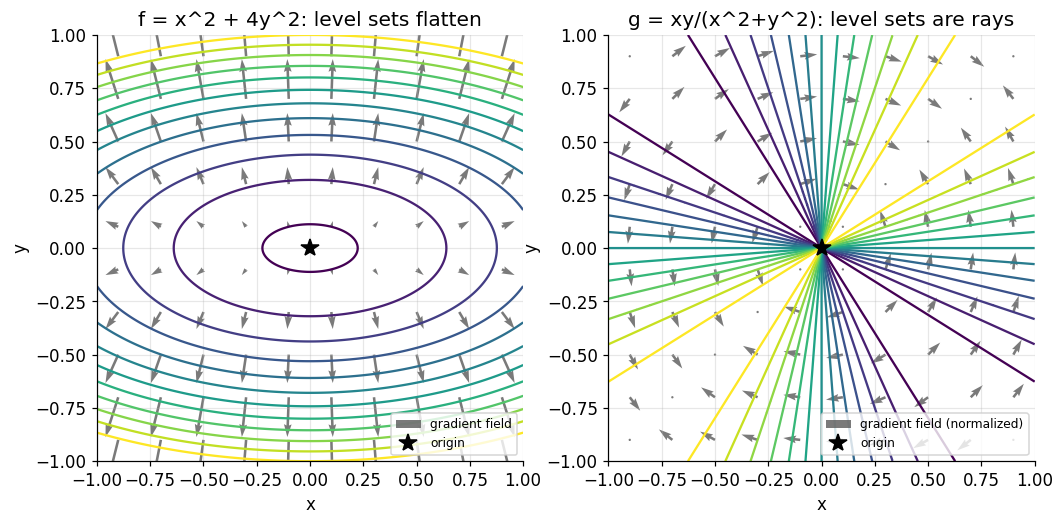

radius 0.5    g on the x-axis +0.000   on y = x +0.500   on y = -x -0.500
radius 0.05   g on the x-axis +0.000   on y = x +0.500   on y = -x -0.500
radius 0.005  g on the x-axis +0.000   on y = x +0.500   on y = -x -0.500


In [2]:
grid = np.linspace(-1.0, 1.0, 400)
X, Y = np.meshgrid(grid, grid)
F = X**2 + 4.0 * Y**2

R2 = X**2 + Y**2
G = np.divide(X * Y, R2, out=np.zeros_like(X), where=R2 > 0)

qs = np.linspace(-0.9, 0.9, 10)   # even count, so the singular origin is skipped
Xq, Yq = np.meshgrid(qs, qs)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.2))

axes[0].contour(X, Y, F, levels=np.linspace(0.05, 4.0, 12), cmap="viridis")
axes[0].quiver(Xq, Yq, 2.0 * Xq, 8.0 * Yq, color="0.35", alpha=0.8,
               scale=60, label="gradient field")
axes[0].plot([0.0], [0.0], "k*", ms=12, label="origin")
axes[0].set_title("f = x^2 + 4y^2: level sets flatten")

Rq2 = Xq**2 + Yq**2
Gx = (Yq * (Yq**2 - Xq**2)) / Rq2**2
Gy = (Xq * (Xq**2 - Yq**2)) / Rq2**2
norm = np.hypot(Gx, Gy)
norm = np.where(norm > 0.0, norm, 1.0)   # the field vanishes where |x| = |y|
axes[1].contour(X, Y, G, levels=np.linspace(-0.45, 0.45, 13), cmap="viridis")
axes[1].quiver(Xq, Yq, Gx / norm, Gy / norm, color="0.35", alpha=0.8,
               scale=25, label="gradient field (normalized)")
axes[1].plot([0.0], [0.0], "k*", ms=12, label="origin")
axes[1].set_title("g = xy/(x^2+y^2): level sets are rays")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="lower right", fontsize=8)
plt.show()

g_at = lambda x, y: x * y / (x**2 + y**2)
for rad in (0.5, 0.05, 0.005):
    print(f"radius {rad:<6} g on the x-axis {g_at(rad, 0.0):+.3f}"
          f"   on y = x {g_at(rad, rad):+.3f}   on y = -x {g_at(rad, -rad):+.3f}")

On the left the level curves are nested ellipses. Near any point they are close to equally
spaced parallel lines, and the gradient arrows are close to constant: a single plane fits the
surface there.

On the right the level curves of $g$ are **straight rays through the origin**, and the value of
$g$ on a ray does not depend on how far along the ray you are. Zooming in changes nothing.

The printed values make the failure concrete: $g$ is $0$ on both axes, $+1/2$ on the line
$y = x$ and $-1/2$ on $y = -x$, at every radius. Both partial derivatives at the origin exist and
are $0$, yet $g$ has no limit at the origin at all.

## 3. Definitions

Throughout, $f$ maps an open set of $\mathbb{R}^n$ into $\mathbb{R}^m$, vectors are columns, and
$\lVert x \rVert = (\sum_i x_i^2)^{1/2}$ is the Euclidean norm. Symbols follow
[the notation register](../../docs/notation.md): the gradient $\nabla f$ is a column vector, the
Jacobian $J_f$ is $m \times n$, and $\varepsilon, \delta$ are the limit quantifiers.

### Definition 3.1 — Balls, open sets, domains

For $a \in \mathbb{R}^n$ and $r \gt 0$ the **open ball** is

$$
B_r(a) = \lbrace x \in \mathbb{R}^n : \lVert x - a \rVert \lt r \rbrace .
$$

A set $U \subseteq \mathbb{R}^n$ is **open** when every $x \in U$ has some $B_r(x) \subseteq U$,
and a **domain** is an open connected set.

Openness is what lets a definition speak about *all* directions of approach: if $a$ sat on a
boundary, some directions would leave the set and the limit below would be vacuous in them.

### Definition 3.2 — Level set

For $f : U \subseteq \mathbb{R}^n \to \mathbb{R}$ and $c \in \mathbb{R}$, the **level set** is

$$
S_c = \lbrace x \in U : f(x) = c \rbrace .
$$

For $n = 2$ these are the level curves drawn in Section 2; for $n = 3$ they are level surfaces.

### Definition 3.3 — Limit

Let $a$ be a limit point of $U$. Then $\lim_{x \to a} f(x) = L$ means: for every
$\varepsilon \gt 0$ there is $\delta \gt 0$ such that

$$
0 \lt \lVert x - a \rVert \lt \delta \implies \lVert f(x) - L \rVert \lt \varepsilon .
$$

The quantifier is over the whole punctured ball, not over a list of curves. That single word
"whole" is the entire difference between the one- and several-variable theories: a limit may
exist along every straight line and still fail to exist.

### Definition 3.4 — Continuity

$f$ is **continuous at** $a \in U$ when $\lim_{x \to a} f(x) = f(a)$, and continuous on $U$ when
it is continuous at every point of $U$.

### Definition 3.5 — Partial derivative

With $e_i$ the $i$-th standard basis vector,

$$
\frac{\partial f}{\partial x_i}(a) = \partial_i f(a) = \lim_{t \to 0} \frac{f(a + t e_i) - f(a)}{t},
$$

whenever the limit exists. For scalar $f$ this is the slope of the curve cut out of the graph by
the plane through $a$ parallel to the $x_i$-axis.

### Definition 3.6 — Directional derivative, and a convention

For $v \in \mathbb{R}^n$,

$$
D_v f(a) = \lim_{t \to 0} \frac{f(a + t v) - f(a)}{t} ,
$$

whenever the limit exists. Taking $v = e_i$ recovers Definition 3.5.

> **Convention.** This module says "**all directional derivatives exist at $a$**" for the bare
> statement that $D_v f(a)$ exists for every $v$, and reserves "**Gateaux differentiable**" for
> the standard stronger requirement that additionally $v \mapsto D_v f(a)$ be linear. Many texts
> use the weak reading; under the standard one, Example 6.6 (iii) is not Gateaux differentiable
> and the sentence "Gateaux plus continuous does not imply Frechet" would be vacuous. Keeping the
> two names apart is what makes Proposition 4.6 a real statement.

### Definition 3.7 — Frechet derivative, Jacobian, gradient

$f$ is **(Frechet) differentiable at** $a \in U$ when there is a linear map
$L : \mathbb{R}^n \to \mathbb{R}^m$ with

$$
\lim_{h \to 0} \frac{\lVert f(a+h) - f(a) - L h \rVert}{\lVert h \rVert} = 0 ,
$$

equivalently $f(a+h) = f(a) + Lh + E(h)$ with $\lVert E(h) \rVert = o(\lVert h \rVert)$.

By Theorem 4.1 such an $L$ is unique; it is written $Df(a)$, and its matrix in the standard bases
is the **Jacobian**

$$
J_f(a) = \bigl[ \partial_j f_i(a) \bigr]_{i \le m, \, j \le n} \in \mathbb{R}^{m \times n} .
$$

For $m = 1$ the **gradient** is the column vector $\nabla f(a)$ with $J_f(a) = \nabla f(a)^\top$.

### Definition 3.8 — The class $C^1$

$f$ is **$C^1$ on $U$** when every partial derivative $\partial_j f_i$ exists at every point of
$U$ and is continuous on $U$.

Only continuity *at the single point $a$* is needed for Theorem 4.2; requiring it on all of $U$
is the convenient global version.

## 4. Main Results

Theorem 4.1 fixes what the derivative is and what it immediately gives. Theorem 4.2 — the result
this module is named after — is the usable criterion: it converts a statement about one linear
map into a statement about $n$ ordinary one-variable derivatives.

Theorems 4.3 to 4.5 are the three tools that make the derivative calculable: the chain rule, the
symmetry of second derivatives, and the substitute for the mean value theorem. Proposition 4.6
records exactly which converses fail and with which counterexample. Theorem 4.7 and Proposition
4.8 point at the next level of the theory and prove the half of it this module supports.

### Theorem 4.1 — Uniqueness of the derivative, and its first consequences

Let $f : U \subseteq \mathbb{R}^n \to \mathbb{R}^m$ be differentiable at $a \in U$ in the sense
of Definition 3.7. Then:

1. the linear map $L$ is unique;
2. $f$ is continuous at $a$;
3. $D_v f(a)$ exists for every $v \in \mathbb{R}^n$ and equals $Lv$, so $v \mapsto D_v f(a)$ is
   linear;
4. every partial derivative exists at $a$ and $L = J_f(a)$; for $m = 1$,
   $D_v f(a) = \nabla f(a)^\top v$.

**Hypotheses.** Only differentiability at the one point $a$, and $U$ open so that $a + h \in U$
for all small $h$. Nothing is assumed about neighbouring points, which is why the conclusion is
pointwise: differentiability at $a$ does **not** make the partials continuous at $a$
(Example 6.6 (iv)).

Proved as Proof 5.1.

### Theorem 4.2 — Continuous partial derivatives imply differentiability

Let $f : U \subseteq \mathbb{R}^n \to \mathbb{R}^m$ with $U$ open and $a \in U$. Suppose

- every partial derivative $\partial_j f_i$ exists at every point of some ball $B_r(a) \subseteq U$, and
- every $\partial_j f_i$ is continuous **at $a$**.

Then $f$ is differentiable at $a$, and $Df(a)$ is the Jacobian $J_f(a)$.

In particular a $C^1$ function is differentiable at every point of $U$.

**Why each hypothesis is needed.** Existence of the partials *in a neighbourhood* is what lets
the mean value theorem be applied on each coordinate segment; existence at $a$ alone is not
enough, and existence everywhere without continuity is not enough either — Example 6.6 (i) has
partials everywhere off a set of lines and is not even continuous at the origin, and Example
6.6 (ii) has *all* directional derivatives at the origin and is still discontinuous there.

**The converse is false.** Example 6.6 (iv) is differentiable at the origin with $Df(0) = 0$
while $\partial_x f$ is unbounded in every neighbourhood of the origin. So $C^1$ is sufficient,
never necessary.

Proved as Proof 5.2. This is the theorem the module exists to establish.

### Theorem 4.3 — Chain rule

Let $U \subseteq \mathbb{R}^n$ and $V \subseteq \mathbb{R}^m$ be open, let
$f : U \to \mathbb{R}^m$ with $f(U) \subseteq V$, and let $g : V \to \mathbb{R}^p$. If $f$ is
differentiable at $a$ and $g$ is differentiable at $b = f(a)$, then $g \circ f$ is differentiable
at $a$ and

$$
D(g \circ f)(a) = Dg(b) \, Df(a), \qquad J_{g \circ f}(a) = J_g(b) \, J_f(a) .
$$

**Hypotheses.** Differentiability of $f$ at $a$, not merely the existence of its partials: the
proof needs the $o(\lVert h \rVert)$ remainder of $f$ to feed the remainder of $g$. Existence of
all directional derivatives is not enough, because those do not compose — Example 6.6 (iii) has
every directional derivative at the origin and no derivative there.

**Interpretation.** Composition of maps becomes multiplication of matrices. Read right to left it
is forward-mode differentiation; read left to right it is reverse mode, which is backpropagation
(Section 8.1).

Proved as Proof 5.3.

### Theorem 4.4 — Schwarz's theorem on mixed partial derivatives

Let $f$ be real valued on an open $U \subseteq \mathbb{R}^2$ and let $(a,b) \in U$. Suppose

- $\partial_x f$ and $\partial_y f$ exist on $U$,
- $\partial_y \partial_x f$ exists on $U$,
- $\partial_y \partial_x f$ is continuous at $(a,b)$.

Then $\partial_x \partial_y f(a,b)$ exists and

$$
\frac{\partial^2 f}{\partial x \, \partial y}(a,b) = \frac{\partial^2 f}{\partial y \, \partial x}(a,b) .
$$

**Hypotheses.** Continuity of the mixed partial at the single point $(a,b)$ is the whole content;
drop it and the conclusion fails, as Peano's function in Example 6.4 shows with
$f_{xy}(0,0) = -1$ and $f_{yx}(0,0) = +1$. Note the theorem does **not** assume that the second
mixed partial in the other order exists — that is part of the conclusion.

**Corollary (the version used in practice).** If $f \in C^2(U)$ then all second partials commute
on $U$; by induction, for $f \in C^k$ any $\le k$ derivatives may be taken in any order.

Proved as Proof 5.4.

### Theorem 4.5 — Mean value inequality in $\mathbb{R}^n$

Let $U \subseteq \mathbb{R}^n$ be open and convex, let $f : U \to \mathbb{R}^m$ be differentiable
on $U$, and suppose $\lVert Df(x) \rVert_{\mathrm{op}} \le M$ for all $x \in U$. Then for all
$x, y \in U$,

$$
\lVert f(y) - f(x) \rVert \le M \lVert y - x \rVert .
$$

For $m = 1$ the sharper equality form survives: there is $c$ on the open segment $(x,y)$ with
$f(y) - f(x) = \nabla f(c)^\top (y - x)$.

**Hypotheses.** Convexity keeps the segment inside $U$. For $m \ge 2$ the equality form is
**false** — no single $c$ serves all $m$ components at once, as Example 6.5 shows — which is
exactly why the inequality is the right tool.

Proved as Proof 5.5.

### Proposition 4.6 — The hierarchy is strict

Write the four conditions at a point $a$:

- (P) every partial derivative exists at $a$;
- (A) every directional derivative $D_v f(a)$ exists;
- (F) $f$ is differentiable at $a$;
- (C) the partials exist near $a$ and are continuous at $a$.

Then $\text{(C)} \Rightarrow \text{(F)} \Rightarrow \text{(A)} \Rightarrow \text{(P)}$, and $f$
differentiable at $a$ implies $f$ continuous at $a$. Every remaining implication is false:

| claimed implication | status | counterexample |
|---|---|---|
| (P) $\Rightarrow$ continuity | false | $xy/(x^2+y^2)$ |
| (A) $\Rightarrow$ continuity | false | $x^2 y/(x^4+y^2)$ |
| (A) and continuity $\Rightarrow$ (F) | false | $x^3/(x^2+y^2)$ |
| (F) $\Rightarrow$ (C) | false | $(x^2+y^2)\sin\bigl(1/(x^2+y^2)\bigr)$ |
| continuity $\Rightarrow$ (P) | false | $\lvert x \rvert$ |

All four counterexample functions are extended by the value $0$ at the origin, and all five rows
are evaluated in code in Section 7.3.

**A correction worth stating explicitly.** Continuity at a point does **not** imply that the
partial derivatives exist there: $f(x,y) = \lvert x \rvert$ is continuous on all of
$\mathbb{R}^2$ and has no $\partial_x f$ anywhere on the line $x = 0$. Continuity and (P) are
incomparable conditions, not nested ones.

Proved as Proof 5.6.

### Theorem 4.7 (cited, not proved here) — Inverse function theorem

Let $f : U \subseteq \mathbb{R}^n \to \mathbb{R}^n$ be $C^1$ on an open $U$, let $a \in U$, and
suppose $J_f(a)$ is invertible. Then there are open sets $V \ni a$ and $W \ni f(a)$ such that
$f : V \to W$ is a bijection, the inverse $f^{-1} : W \to V$ is $C^1$, and

$$
J_{f^{-1}}(f(x)) = J_f(x)^{-1} \qquad \text{for all } x \in V .
$$

**Why it is not proved here.** The surjectivity half needs the contraction mapping principle on a
complete metric space, which this area does not develop until
[calculus/15](../15_ordinary_differential_equations/) uses it for Picard iteration. Proving it
inline would double the length of this module for a tool it does not use.

Source: Rudin, *Principles of Mathematical Analysis*, 3rd ed., Theorem 9.24; the implicit
function theorem is Theorem 9.28 there, and Hubbard and Hubbard, *Vector Calculus, Linear
Algebra, and Differential Forms*, section 2.10, give the same proof with the contraction step
spelled out.

The **injectivity half is proved in full** below, because it needs only Theorem 4.5.

### Proposition 4.8 — An invertible derivative forces local injectivity

Let $f : U \to \mathbb{R}^n$ be $C^1$ on an open $U \subseteq \mathbb{R}^n$, let $a \in U$, and
suppose $A = J_f(a)$ is invertible. Put

$$
\lambda = \frac{1}{2 \lVert A^{-1} \rVert_{\mathrm{op}}} \gt 0 .
$$

Then there is a ball $B = B_r(a) \subseteq U$ on which

$$
\lVert f(y) - f(x) \rVert \ge \lambda \lVert y - x \rVert \qquad \text{for all } x, y \in B ,
$$

so $f$ is injective on $B$.

**Interpretation.** An invertible derivative is not merely a non-degeneracy condition: it gives a
quantitative lower bound, and the bound degrades exactly like the condition number of $J_f(a)$.
That constant is what makes Newton's method well posed near a regular root.

Proved as Proof 5.7.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Uniqueness.** Suppose $L_1$ and $L_2$ both satisfy Definition 3.7 and put $M = L_1 - L_2$. For
fixed $v \neq 0$ and $t \gt 0$ take $h = tv$:

$$
\frac{\lVert M(tv) \rVert}{\lVert tv \rVert} = \frac{\lVert Mv \rVert}{\lVert v \rVert} ,
$$

because $M$ is linear and the factor $t$ cancels. The left side is bounded by the sum of the two
remainder quotients, both of which tend to $0$ as $t \to 0^+$. The right side does not depend on
$t$, so it is $0$, so $Mv = 0$. As $v$ was arbitrary, $L_1 = L_2$.

**Continuity.** From $f(a+h) - f(a) = Lh + E(h)$ and $\lVert Lh \rVert \le \lVert L \rVert_{\mathrm{op}} \lVert h \rVert$,

$$
\lVert f(a+h) - f(a) \rVert \le \lVert L \rVert_{\mathrm{op}} \lVert h \rVert + \frac{\lVert E(h) \rVert}{\lVert h \rVert} \lVert h \rVert .
$$

Both terms tend to $0$ with $\lVert h \rVert$, the second because its first factor tends to $0$
and its second is bounded. Hence $f(a+h) \to f(a)$.

**Directional derivatives.** Put $h = tv$ with $v \neq 0$ fixed and $t \neq 0$:

$$
\frac{f(a + tv) - f(a)}{t} = Lv + \frac{E(tv)}{t} .
$$

The remainder obeys

$$
\left\lVert \frac{E(tv)}{t} \right\rVert = \lVert v \rVert \cdot \frac{\lVert E(tv) \rVert}{\lVert tv \rVert} \xrightarrow[t \to 0]{} 0 ,
$$

so $D_v f(a) = Lv$, which is linear in $v$ because $L$ is.

**The matrix.** Taking $v = e_j$ gives $\partial_j f(a) = L e_j$, the $j$-th column of the matrix
of $L$. Stacking components, that matrix is $J_f(a)$. For $m = 1$, $L v = \nabla f(a)^\top v$.
$\blacksquare$

### Proof 5.2 (of Theorem 4.2, continuous partials imply differentiability)

It suffices to treat $m = 1$: a vector-valued $f$ is differentiable at $a$ exactly when each
component is, since the defining quotient for $f$ is bounded above by the sum of the component
quotients and below by each of them.

So let $f : B_r(a) \to \mathbb{R}$ have all $n$ partials on $B_r(a)$, continuous at $a$, and let
$\lVert h \rVert \lt r$.

**Step 1 — telescope along the coordinate directions.** Define the intermediate points

$$
p_0 = a, \qquad p_k = a + \sum_{j \le k} h_j e_j \quad (k = 1, \dots, n),
$$

so $p_n = a + h$. Each $p_k$ lies in $B_r(a)$ because $\lVert p_k - a \rVert \le \lVert h \rVert$.
Telescoping,

$$
f(a+h) - f(a) = \sum_{k=1}^{n} \bigl[ f(p_k) - f(p_{k-1}) \bigr] .
$$

Every bracket changes exactly one coordinate. This is the step that converts an $n$-dimensional
increment into $n$ one-dimensional ones.

**Step 2 — apply the one-variable mean value theorem to each bracket.** Fix $k$ and consider

$$
\varphi_k(s) = f(p_{k-1} + s e_k), \qquad s \text{ between } 0 \text{ and } h_k .
$$

By hypothesis $\partial_k f$ exists on $B_r(a)$, so $\varphi_k$ is differentiable with
$\varphi_k'(s) = \partial_k f(p_{k-1} + s e_k)$, hence continuous. The mean value theorem gives
$\theta_k$ strictly between $0$ and $h_k$ with

$$
f(p_k) - f(p_{k-1}) = \varphi_k(h_k) - \varphi_k(0) = h_k \, \partial_k f(q_k), \qquad q_k = p_{k-1} + \theta_k e_k .
$$

Note $\lVert q_k - a \rVert \le \lVert h \rVert$, so $q_k \to a$ as $h \to 0$.

**Step 3 — subtract the candidate linear map.** With $L h = \sum_k h_k \, \partial_k f(a)$,

$$
f(a+h) - f(a) - Lh = \sum_{k=1}^{n} h_k \bigl[ \partial_k f(q_k) - \partial_k f(a) \bigr] .
$$

**Step 4 — estimate.** Since $\lvert h_k \rvert \le \lVert h \rVert$,

$$
\frac{\lvert f(a+h) - f(a) - Lh \rvert}{\lVert h \rVert} \le \sum_{k=1}^{n} \bigl\lvert \partial_k f(q_k) - \partial_k f(a) \bigr\rvert .
$$

Continuity of each $\partial_k f$ at $a$, together with $q_k \to a$, sends every summand to $0$.
There are finitely many summands, so the whole bound tends to $0$ and $f$ is differentiable at
$a$ with $Df(a) = L$. By Theorem 4.1 (4), $L = J_f(a)$. $\blacksquare$

**Where the hypotheses entered.** Step 2 used existence of $\partial_k f$ at every point of the
segment, not only at $a$; Step 4 used continuity only at the single point $a$. Nothing used
continuity of $f$ itself, which is a conclusion.

### Proof 5.3 (of Theorem 4.3, chain rule)

Write $A = Df(a)$, $B = Dg(b)$ with $b = f(a)$, and define the two remainders

$$
u(h) = f(a+h) - f(a) - Ah, \qquad w(k) = g(b+k) - g(b) - Bk ,
$$

so $\lVert u(h) \rVert = o(\lVert h \rVert)$ and $\lVert w(k) \rVert = o(\lVert k \rVert)$.

**Step 1 — substitute.** Put $k(h) = f(a+h) - f(a) = Ah + u(h)$. Then

$$
g(f(a+h)) - g(f(a)) = B k(h) + w(k(h)) = BAh + B u(h) + w(k(h)) .
$$

So the claim is exactly that $B u(h) + w(k(h)) = o(\lVert h \rVert)$.

**Step 2 — the first term.** $\lVert B u(h) \rVert \le \lVert B \rVert_{\mathrm{op}} \lVert u(h) \rVert = o(\lVert h \rVert)$,
since $\lVert B \rVert_{\mathrm{op}}$ is a fixed constant.

**Step 3 — control the inner step size.** For $\lVert h \rVert$ small enough that
$\lVert u(h) \rVert \le \lVert h \rVert$,

$$
\lVert k(h) \rVert \le \lVert A \rVert_{\mathrm{op}} \lVert h \rVert + \lVert h \rVert = C \lVert h \rVert, \qquad C = \lVert A \rVert_{\mathrm{op}} + 1 .
$$

The inner increment is therefore at most a constant multiple of the outer one.

**Step 4 — the second term.** Given $\varepsilon \gt 0$, differentiability of $g$ at $b$ gives
$\eta \gt 0$ with $\lVert w(k) \rVert \le (\varepsilon/C) \lVert k \rVert$ whenever
$\lVert k \rVert \lt \eta$; this also holds at $k = 0$, where $w(0) = 0$. Choose
$\lVert h \rVert$ small enough that both Step 3 applies and $C \lVert h \rVert \lt \eta$. Then

$$
\lVert w(k(h)) \rVert \le \frac{\varepsilon}{C} \lVert k(h) \rVert \le \frac{\varepsilon}{C} \cdot C \lVert h \rVert = \varepsilon \lVert h \rVert .
$$

As $\varepsilon$ was arbitrary, $\lVert w(k(h)) \rVert = o(\lVert h \rVert)$.

**Step 5 — conclude.** Both remainder pieces are $o(\lVert h \rVert)$, so $g \circ f$ is
differentiable at $a$ with derivative $BA$. Passing to matrices in the standard bases gives
$J_{g \circ f}(a) = J_g(b) J_f(a)$. $\blacksquare$

**Interpretation.** Step 4 is the only delicate point, and it is where "differentiable" is
strictly stronger than "all directional derivatives exist": the bound on $w$ must hold for the
*actual* increment $k(h)$, which need not lie along any fixed ray.

### Proof 5.4 (of Theorem 4.4, Schwarz)

Abbreviate $\partial_y \partial_x f$ by $f_{xy}$ and $\partial_x \partial_y f$ by $f_{yx}$, and
work with the **double difference**

$$
\Delta(h,k) = \bigl[ f(a+h, b+k) - f(a+h, b) \bigr] - \bigl[ f(a, b+k) - f(a, b) \bigr] ,
$$

defined for all small non-zero $h, k$ because $U$ is open. It is symmetric in the two variables
by construction, which is the whole idea of the proof.

**Step 1 — two mean value theorems.** Fix $k$ and set $\psi(x) = f(x, b+k) - f(x, b)$, so that
$\Delta(h,k) = \psi(a+h) - \psi(a)$. Since $\partial_x f$ exists on $U$, $\psi$ is differentiable
and the mean value theorem gives $x^{\ast}$ strictly between $a$ and $a+h$ with

$$
\Delta(h,k) = h \, \psi'(x^{\ast}) = h \bigl[ \partial_x f(x^{\ast}, b+k) - \partial_x f(x^{\ast}, b) \bigr] .
$$

The auxiliary function is called $\psi$, not $h$: the symbol $h$ already denotes the increment.

Now $y \mapsto \partial_x f(x^{\ast}, y)$ is differentiable because $f_{xy}$ exists on $U$, so a
second mean value theorem gives $y^{\ast}$ strictly between $b$ and $b+k$ with

$$
\Delta(h,k) = h k \, f_{xy}(x^{\ast}, y^{\ast}) .
$$

**Step 2 — use continuity at the one point.** Let $\varepsilon \gt 0$. Continuity of $f_{xy}$ at
$(a,b)$ gives $\delta \gt 0$ with

$$
\lvert f_{xy}(x,y) - f_{xy}(a,b) \rvert \lt \varepsilon \quad \text{whenever } \lVert (x,y) - (a,b) \rVert \lt \delta .
$$

If $0 \lt \lvert h \rvert \lt \delta/2$ and $0 \lt \lvert k \rvert \lt \delta/2$ then
$(x^{\ast}, y^{\ast})$ is inside that ball, so

$$
\left\lvert \frac{\Delta(h,k)}{hk} - f_{xy}(a,b) \right\rvert \lt \varepsilon .
$$

**Step 3 — let $k \to 0$ with $h$ fixed.** Because $\partial_y f$ exists on $U$,

$$
\lim_{k \to 0} \frac{\Delta(h,k)}{k} = \partial_y f(a+h, b) - \partial_y f(a, b) .
$$

Dividing by $h$ and passing to the limit inside the inequality of Step 2 — a non-strict
inequality survives a limit — gives, for every $h$ with $0 \lt \lvert h \rvert \lt \delta/2$,

$$
\left\lvert \frac{\partial_y f(a+h,b) - \partial_y f(a,b)}{h} - f_{xy}(a,b) \right\rvert \le \varepsilon .
$$

**Step 4 — read off the conclusion.** The displayed quotient is exactly the difference quotient
whose limit as $h \to 0$ defines $f_{yx}(a,b)$. The inequality says that quotient stays within
$\varepsilon$ of the fixed number $f_{xy}(a,b)$ for all small $h$, and $\varepsilon$ was
arbitrary. Hence the limit exists and

$$
f_{yx}(a,b) = f_{xy}(a,b) . \qquad \blacksquare
$$

**What was and was not assumed.** Existence of $f_{yx}$ anywhere was never assumed; it came out.
Continuity was used at one point only. Both facts are what make Peano's function in Example 6.4 a
genuine counterexample rather than a violation of the theorem: there $f_{xy}$ exists everywhere
but is discontinuous at the origin.

### Proof 5.5 (of Theorem 4.5, mean value inequality)

Fix $x, y \in U$ and set $\gamma(t) = x + t(y-x)$ for $t \in [0,1]$, which stays in $U$ by
convexity.

**The scalar case first.** For $m = 1$ let $\varphi(t) = f(\gamma(t))$. By Theorem 4.3,
$\varphi'(t) = \nabla f(\gamma(t))^\top (y-x)$, and the one-variable mean value theorem gives
$t_0 \in (0,1)$ with $f(y) - f(x) = \varphi(1) - \varphi(0) = \nabla f(\gamma(t_0))^\top (y-x)$.
Cauchy-Schwarz then bounds this by $M \lVert y - x \rVert$.

**The vector case.** For $m \ge 2$ no single $t_0$ need work for all components, so project onto
one direction instead. Put $z = f(y) - f(x)$. If $z = 0$ there is nothing to prove, so assume
$z \neq 0$ and define the scalar function

$$
\varphi(t) = z^\top f(\gamma(t)) .
$$

By Theorem 4.3, $\varphi$ is differentiable with $\varphi'(t) = z^\top Df(\gamma(t)) (y-x)$. The
one-variable mean value theorem gives $t_0 \in (0,1)$ with

$$
\lVert z \rVert^2 = z^\top z = \varphi(1) - \varphi(0) = z^\top Df(\gamma(t_0)) (y - x) .
$$

Cauchy-Schwarz and the operator-norm bound give

$$
\lVert z \rVert^2 \le \lVert z \rVert \cdot \lVert Df(\gamma(t_0)) (y-x) \rVert \le \lVert z \rVert \, M \, \lVert y - x \rVert .
$$

Dividing by $\lVert z \rVert \gt 0$ finishes the proof. $\blacksquare$

**Interpretation.** The trick is to test the vector increment against itself, which turns $m$
uncoordinated mean value theorems into a single scalar one. The price is that the conclusion is
an inequality; Example 6.5 shows the price is unavoidable.

### Proof 5.6 (of Proposition 4.6)

The forward implications are Theorem 4.2 for (C) $\Rightarrow$ (F), and Theorem 4.1 for
(F) $\Rightarrow$ (A) $\Rightarrow$ (P) and for continuity. Only the failures need work; all four
functions below take the value $0$ at the origin.

**(i) Partials without continuity.** $f(x,y) = xy/(x^2+y^2)$. On both axes $f \equiv 0$, so
$f_x(0,0) = f_y(0,0) = 0$. But $f(t,t) = 1/2$ for every $t \neq 0$, so $f$ has no limit at the
origin.

**(ii) All directional derivatives without continuity.** $f(x,y) = x^2 y/(x^4+y^2)$. For
$v = (v_1, v_2)$ with $v_2 \neq 0$,

$$
\frac{f(tv)}{t} = \frac{t^3 v_1^2 v_2}{t \, ( t^4 v_1^4 + t^2 v_2^2 )} = \frac{v_1^2 v_2}{t^2 v_1^4 + v_2^2} \xrightarrow[t \to 0]{} \frac{v_1^2}{v_2} ,
$$

and for $v_2 = 0$ the quotient is identically $0$. So every $D_v f(0,0)$ exists. Yet
$f(t, t^2) = 1/2$ for $t \neq 0$, so $f$ is discontinuous at the origin.

Note also that $v \mapsto D_v f(0,0) = v_1^2/v_2$ is wildly non-linear, so this $f$ is not
Gateaux differentiable in the sense of the convention in Definition 3.6 either.

**(iii) Continuity and all directional derivatives without differentiability.**
$f(x,y) = x^3/(x^2+y^2)$. In polar form $f = r \cos^3\theta$, so
$\lvert f \rvert \le r \to 0$ and $f$ is continuous at the origin. Also

$$
\frac{f(tv)}{t} = \frac{t^3 v_1^3}{t \cdot t^2 \lVert v \rVert^2} = \frac{v_1^3}{\lVert v \rVert^2} ,
$$

so $D_v f(0,0) = v_1^3 / \lVert v \rVert^2$ for every $v$, with no limit taken. But
$D_{(1,0)}f + D_{(0,1)}f = 1 + 0 = 1$ while $D_{(1,1)}f = 1/2$, so $v \mapsto D_v f(0,0)$ is not
linear and Theorem 4.1 (3) rules out differentiability.

Equivalently, with $L h = h_1$ read off the partials, the remainder is
$f(h) - h_1 = -h_1 h_2^2 / \lVert h \rVert^2$, whose quotient by $\lVert h \rVert$ equals
$\lvert \cos\theta \sin^2\theta \rvert$ — independent of $r$, with supremum
$2/(3\sqrt{3}) \approx 0.3849$. It does not tend to $0$.

**(iv) Differentiability without $C^1$.** $f(x,y) = (x^2+y^2)\sin\bigl(1/(x^2+y^2)\bigr)$. With
$r = \lVert h \rVert$,

$$
\frac{\lvert f(h) - 0 \rvert}{r} = \frac{r^2 \lvert \sin(1/r^2) \rvert}{r} \le r \to 0 ,
$$

so $f$ is differentiable at the origin with $Df(0) = 0$. Away from the origin

$$
\partial_x f(x,y) = 2x \sin\!\left(\frac{1}{x^2+y^2}\right) - \frac{2x}{x^2+y^2} \cos\!\left(\frac{1}{x^2+y^2}\right) ,
$$

whose second term is unbounded along $y = 0$ as $x \to 0$. So $\partial_x f$ is not continuous at
the origin and $f$ is not $C^1$ there.

**(v) Continuity without partials.** $f(x,y) = \lvert x \rvert$ is continuous everywhere, and for
any $b$ the quotient $(\lvert t \rvert - 0)/t = \operatorname{sign}(t)$ has no limit, so
$\partial_x f(0,b)$ does not exist. $\blacksquare$

### Proof 5.7 (of Proposition 4.8, local injectivity)

Let $A = J_f(a)$, invertible, and $\lambda = 1/(2\lVert A^{-1} \rVert_{\mathrm{op}})$.

**Step 1 — a ball where the derivative barely moves.** $f$ is $C^1$, so $x \mapsto J_f(x)$ is
continuous at $a$ and there is $r \gt 0$ with $B = B_r(a) \subseteq U$ and

$$
\lVert J_f(x) - A \rVert_{\mathrm{op}} \lt \lambda \qquad \text{for all } x \in B .
$$

A ball is convex, which is what Theorem 4.5 needs.

**Step 2 — apply the mean value inequality to the deviation.** Define
$\varphi(x) = f(x) - Ax$ on $B$. It is differentiable with $D\varphi(x) = J_f(x) - A$, so
$\lVert D\varphi \rVert_{\mathrm{op}} \lt \lambda$ on $B$ and Theorem 4.5 gives, for $x, y \in B$,

$$
\lVert \varphi(y) - \varphi(x) \rVert \le \lambda \lVert y - x \rVert .
$$

**Step 3 — a lower bound on $A$.** For any $u$, $\lVert u \rVert = \lVert A^{-1} A u \rVert \le \lVert A^{-1} \rVert_{\mathrm{op}} \lVert Au \rVert$,
hence

$$
\lVert A u \rVert \ge \frac{\lVert u \rVert}{\lVert A^{-1} \rVert_{\mathrm{op}}} = 2\lambda \lVert u \rVert .
$$

**Step 4 — combine.** Writing $f(y) - f(x) = A(y-x) + \bigl[\varphi(y) - \varphi(x)\bigr]$ and
using the reverse triangle inequality,

$$
\lVert f(y) - f(x) \rVert \ge \lVert A(y-x) \rVert - \lVert \varphi(y) - \varphi(x) \rVert \ge 2\lambda \lVert y - x \rVert - \lambda \lVert y - x \rVert = \lambda \lVert y - x \rVert .
$$

If $f(y) = f(x)$ the left side is $0$, forcing $y = x$. So $f$ is injective on $B$.
$\blacksquare$

## 6. Worked Examples

Every example is small enough to finish with pen and paper, and each main result of Section 4
gets one. Two code cells recompute the numbers and assert agreement.

### Example 6.1 — The derivative as a linear map (Theorem 4.1)

Take $f(x,y) = x^2 y$ at $a = (1,2)$, where $f(a) = 2$.

*Partials.* $\partial_x f = 2xy$ and $\partial_y f = x^2$, so

$$
\nabla f(1,2) = \begin{pmatrix} 4 \\ 1 \end{pmatrix}, \qquad J_f(1,2) = \begin{pmatrix} 4 & 1 \end{pmatrix} .
$$

*A directional derivative.* For $v = \tfrac{1}{5}(3,4)$, Theorem 4.1 (4) gives

$$
D_v f(1,2) = 4 \cdot \tfrac{3}{5} + 1 \cdot \tfrac{4}{5} = \tfrac{12 + 4}{5} = 3.2 .
$$

*The remainder, exactly.* Expanding with $h = (s,t)$,

$$
f(1+s, 2+t) = (1 + 2s + s^2)(2 + t) = \underbrace{2}_{f(a)} + \underbrace{4s + t}_{J_f(a)h} + \underbrace{2st + 2s^2 + s^2 t}_{E(h)} .
$$

At $h = (0.01, -0.02)$: $E(h) = -0.0004 + 0.0002 - 0.000002 = -0.000202$ and
$\lVert h \rVert = \sqrt{5} \times 10^{-2}$, so

$$
\frac{\lvert E(h) \rvert}{\lVert h \rVert} = \frac{2.02 \times 10^{-4}}{2.2360680 \times 10^{-2}} = 9.0337 \times 10^{-3} .
$$

**Interpretation.** Every term of $E$ is quadratic or higher in $(s,t)$, which is precisely the
$o(\lVert h \rVert)$ statement. Halving $h$ quarters $E$ and halves the quotient.

### Example 6.2 — The proof of Theorem 4.2, instantiated

Run Proof 5.2 on the same $f(x,y) = x^2 y$, $a = (1,2)$, $h = (0.01, -0.02)$.

*Step 1, telescope.* $p_0 = (1,2)$, $p_1 = (1.01, 2)$, $p_2 = (1.01, 1.98)$. Reordering the
telescope to move $y$ first is equally valid; take the order $x$ then $y$.

$$
f(a+h) - f(a) = \bigl[f(1.01, 2) - f(1,2)\bigr] + \bigl[f(1.01, 1.98) - f(1.01, 2)\bigr] .
$$

*Step 2, one mean value theorem per bracket.* The first bracket is
$2(1.01^2 - 1) = 0.0402 = 0.01 \cdot \partial_x f(\xi, 2)$ with
$\partial_x f(\xi,2) = 4\xi = 4.02$, so $\xi = 1.005$ — the midpoint, because $x^2$ is quadratic.

The second bracket is $1.01^2(1.98 - 2) = -0.0202\cdots$, and since
$\partial_y f(1.01, y) = 1.01^2$ does not depend on $y$, any $\eta$ works.

*Step 3, subtract the linear map.*

$$
E(h) = 0.01\bigl[\partial_x f(1.005, 2) - \partial_x f(1,2)\bigr] + (-0.02)\bigl[\partial_y f(1.01, \eta) - \partial_y f(1,2)\bigr]
$$

$$
E(h) = 0.01 \, (4.02 - 4) + (-0.02)(1.0201 - 1) = 0.0002 - 0.000402 = -0.000202 .
$$

**Interpretation.** The number matches Example 6.1 exactly, as it must. The proof does not
estimate $E$ crudely; it *identifies* $E$ as a sum of increments of the partial derivatives, and
continuity of those partials at $a$ is precisely what drives the sum to zero.

### Example 6.3 — Chain rule in polar coordinates (Theorem 4.3)

Let $F(r,\theta) = (r\cos\theta, \; r\sin\theta)$ and $f(x,y) = x^2 y$, and evaluate at
$(r,\theta) = (2, \pi/3)$, so $\cos\theta = \tfrac12$, $\sin\theta = \tfrac{\sqrt3}{2}$ and
$(x,y) = (1, \sqrt3)$.

*The two Jacobians.*

$$
J_F(2, \pi/3) = \begin{pmatrix} \cos\theta & -r\sin\theta \\ \sin\theta & r\cos\theta \end{pmatrix} = \begin{pmatrix} \tfrac12 & -\sqrt3 \\ \tfrac{\sqrt3}{2} & 1 \end{pmatrix}, \qquad J_f(1,\sqrt3) = \begin{pmatrix} 2\sqrt3 & 1 \end{pmatrix} .
$$

*Their product.*

$$
J_f J_F = \begin{pmatrix} 2\sqrt3 \cdot \tfrac12 + 1 \cdot \tfrac{\sqrt3}{2} & \; 2\sqrt3 \cdot (-\sqrt3) + 1 \cdot 1 \end{pmatrix} = \begin{pmatrix} \tfrac{3\sqrt3}{2} & -5 \end{pmatrix} .
$$

*Direct check.* $h(r,\theta) = f(F(r,\theta)) = r^3 \cos^2\theta \sin\theta$, so

$$
\partial_r h = 3r^2 \cos^2\theta \sin\theta = 3 \cdot 4 \cdot \tfrac14 \cdot \tfrac{\sqrt3}{2} = \tfrac{3\sqrt3}{2},
$$

$$
\partial_\theta h = r^3\bigl(\cos^3\theta - 2\cos\theta\sin^2\theta\bigr) = 8\left(\tfrac18 - 2 \cdot \tfrac12 \cdot \tfrac34\right) = 8(0.125 - 0.75) = -5 .
$$

**Interpretation.** Two routes, one answer $(\tfrac{3\sqrt3}{2}, -5) \approx (2.598076, -5)$. The
matrix route never needed the composite formula, which is why it scales to a hundred-layer
network where writing the composite out is impossible.

### Example 6.4 — Schwarz and Peano's counterexample (Theorem 4.4)

**The positive case.** For $f(x,y) = x^3 y^2 + \sin(xy)$, which is $C^\infty$,

$$
f_x = 3x^2y^2 + y\cos(xy), \qquad f_{xy} = 6x^2 y + \cos(xy) - xy\sin(xy),
$$

$$
f_y = 2x^3 y + x\cos(xy), \qquad f_{yx} = 6x^2 y + \cos(xy) - xy\sin(xy) .
$$

At $(1,1)$ both equal $6 + \cos 1 - \sin 1 = 5.698831\ldots$

**Peano's function.** Define

$$
f(x,y) = \frac{xy(x^2-y^2)}{x^2+y^2} \quad \text{for } (x,y) \neq (0,0), \qquad f(0,0) = 0 .
$$

*Step 1 — first partials off the origin.* Differentiating $(x^3 y - x y^3)/(x^2+y^2)$,

$$
f_x(x,y) = \frac{y(x^4 + 4x^2y^2 - y^4)}{(x^2+y^2)^2}, \qquad f_y(x,y) = \frac{x(x^4 - 4x^2y^2 - y^4)}{(x^2+y^2)^2} ,
$$

the second by the antisymmetry $f(y,x) = -f(x,y)$.

*Step 2 — restrict to the axes.* For $y \neq 0$, $f_x(0,y) = y(-y^4)/y^4 = -y$; for $x \neq 0$,
$f_y(x,0) = x \cdot x^4 / x^4 = x$. At the origin $f$ vanishes on both axes, so
$f_x(0,0) = f_y(0,0) = 0$; hence $f_x(0,y) = -y$ and $f_y(x,0) = x$ hold for all $y$ and all $x$.

*Step 3 — the mixed partials at the origin.*

$$
f_{xy}(0,0) = \lim_{k \to 0} \frac{f_x(0,k) - f_x(0,0)}{k} = \lim_{k \to 0} \frac{-k}{k} = -1,
$$

$$
f_{yx}(0,0) = \lim_{h \to 0} \frac{f_y(h,0) - f_y(0,0)}{h} = \lim_{h \to 0} \frac{h}{h} = +1 .
$$

*Step 4 — which hypothesis failed.* Off the origin,

$$
f_{xy}(x,y) = \frac{x^6 + 9x^4y^2 - 9x^2y^4 - y^6}{(x^2+y^2)^3},
$$

and along $y = mx$ with $x \to 0$ this tends to

$$
\frac{1 + 9m^2 - 9m^4 - m^6}{(1+m^2)^3},
$$

which equals $+1$ for $m = 0$, $0$ for $m = 1$ and $-1$ in the limit $m \to \infty$. The limit
depends on $m$, so $f_{xy}$ is discontinuous at the origin and Theorem 4.4 does not apply.

**Interpretation.** Nothing here contradicts Theorem 4.4. Both mixed partials exist everywhere;
the hypothesis that fails is continuity of $f_{xy}$ at the one point where the two answers
differ. Note also that the value $f_{xy}(0,0) = -1$ is not the limit of $f_{xy}$ along the
$x$-axis, which is $+1$: a second derivative need not be continuous even where it exists.

### Example 6.5 — No exact mean value theorem for $m \ge 2$ (Theorem 4.5)

Take $\gamma : \mathbb{R} \to \mathbb{R}^2$, $\gamma(t) = (\cos t, \sin t)$, on $[0, \pi]$. Then
$\gamma'(t) = (-\sin t, \cos t)$ has $\lVert \gamma'(t) \rVert = 1$, so $M = 1$.

*The inequality holds.*

$$
\lVert \gamma(\pi) - \gamma(0) \rVert = \lVert (-1,0) - (1,0) \rVert = 2 \le M(\pi - 0) = \pi = 3.14159\ldots
$$

*The equality fails.* Suppose $\gamma(\pi) - \gamma(0) = \pi \gamma'(c)$ for some $c$. Comparing
second components gives $\pi\cos c = 0$, so $\cos c = 0$ and $\sin c = \pm 1$; comparing first
components gives $-\pi \sin c = -2$, so $\sin c = 2/\pi = 0.63662\ldots$ The two are
incompatible, so no such $c$ exists.

**Interpretation.** Each component separately obeys the mean value theorem, at
$c_1 = \pi/2$ and $c_2 = \pi/2$ respectively — but $\gamma'(\pi/2) = (-1,0)$ and
$\pi \cdot (-1,0) = (-\pi, 0) \neq (-2,0)$. The two components need different intermediate points
for the *scaled* statement to hold, and there is no reason a single one should serve both.

### Example 6.6 — The five rows of Proposition 4.6 on concrete functions

Collected for reference; all four rational functions take the value $0$ at the origin.

| function | $D_v f(0,0)$ | continuous at $0$? | differentiable at $0$? |
|---|---|---|---|
| (i) $xy/(x^2+y^2)$ | exists only for $v_1 v_2 = 0$ | no | no |
| (ii) $x^2y/(x^4+y^2)$ | $v_1^2/v_2$ for $v_2 \neq 0$, else $0$ | no | no |
| (iii) $x^3/(x^2+y^2)$ | $v_1^3/\lVert v \rVert^2$ | yes | no |
| (iv) $(x^2+y^2)\sin\bigl(1/(x^2+y^2)\bigr)$ | $0$ | yes | yes, but not $C^1$ |
| (v) $\lvert x \rvert$ | fails for $v_1 \neq 0$ | yes | no |

**Interpretation.** Rows (i) and (v) together show that continuity and the existence of partials
are *incomparable*: neither implies the other. That is the correction to the hierarchy diagram
this module previously carried.

The next cell recomputes Examples 6.1, 6.2, 6.3 and 6.5 and asserts every number stated by hand.

In [3]:
# --- Example 6.1 ---------------------------------------------------------
f = lambda x, y: x**2 * y
a = np.array([1.0, 2.0])
grad = np.array([2.0 * a[0] * a[1], a[0] ** 2])
v = np.array([3.0, 4.0]) / 5.0
h = np.array([0.01, -0.02])

E = f(*(a + h)) - f(*a) - grad @ h
ratio = abs(E) / np.linalg.norm(h)
print("Example 6.1")
print("  grad f(1,2)          :", grad)
print("  D_v f(1,2)           :", grad @ v)
print(f"  remainder E(h)       : {E:.12f}   (hand value -0.000202)")
print(f"  |E| / ||h||          : {ratio:.7f}")
assert np.allclose(grad, [4.0, 1.0])
assert abs(grad @ v - 3.2) < 1e-12
assert abs(E - (-0.000202)) < 1e-15
assert abs(ratio - 0.000202 / np.sqrt(5e-4)) < 1e-12

# halving h should quarter E and halve the quotient
E2 = f(*(a + h / 2)) - f(*a) - grad @ (h / 2)
print(f"  E(h/2) / E(h)        : {E2 / E:.6f}   (predicted 0.25)")

# --- Example 6.2: the telescope of Proof 5.2 -----------------------------
p0, p1, p2 = a, np.array([1.01, 2.0]), a + h
b1 = f(*p1) - f(*p0)
b2 = f(*p2) - f(*p1)
xi = b1 / (h[0] * 2 * 2.0)           # b1 = h1 * 2*xi*2  =>  xi
E_proof = h[0] * (2 * xi * 2.0 - grad[0]) + h[1] * (p1[0] ** 2 - grad[1])
print("\nExample 6.2")
print(f"  bracket 1, bracket 2 : {b1:.10f}  {b2:.10f}   sum {b1 + b2:.10f}")
print(f"  mean value point xi  : {xi:.10f}   (hand value 1.005)")
print(f"  E from the proof     : {E_proof:.12f}   (Example 6.1 gave {E:.12f})")
assert abs(xi - 1.005) < 1e-12
assert abs(E_proof - E) < 1e-15
assert abs((b1 + b2) - (f(*(a + h)) - f(*a))) < 1e-15

# --- Example 6.3: chain rule --------------------------------------------
r0, th0 = 2.0, np.pi / 3
JF = np.array([[np.cos(th0), -r0 * np.sin(th0)],
               [np.sin(th0),  r0 * np.cos(th0)]])
x0, y0 = r0 * np.cos(th0), r0 * np.sin(th0)
Jf = np.array([[2 * x0 * y0, x0 ** 2]])
prod = Jf @ JF
direct = np.array([[3 * r0**2 * np.cos(th0)**2 * np.sin(th0),
                    r0**3 * (np.cos(th0)**3 - 2 * np.cos(th0) * np.sin(th0)**2)]])
print("\nExample 6.3")
print("  J_f(1,sqrt3) J_F(2,pi/3):", prod)
print("  direct partials of h    :", direct)
print("  hand values             :", np.array([[3 * np.sqrt(3) / 2, -5.0]]))
print(f"  residual                : {np.abs(prod - direct).max():.3e}"
      f"  = {np.abs(prod - direct).max() / EPS:.1f} * eps")
assert np.allclose(prod, direct, atol=1e-12)
assert np.allclose(prod, [[3 * np.sqrt(3) / 2, -5.0]], atol=1e-12)

# --- Example 6.5: no exact MVT for m >= 2 --------------------------------
gam = lambda t: np.array([np.cos(t), np.sin(t)])
dgam = lambda t: np.array([-np.sin(t), np.cos(t)])
lhs = gam(np.pi) - gam(0.0)
ts = np.linspace(0.0, np.pi, 200001)
resid = np.linalg.norm(np.pi * np.stack([-np.sin(ts), np.cos(ts)], axis=1) - lhs, axis=1)
print("\nExample 6.5")
print("  gamma(pi) - gamma(0)    :", lhs, "   norm", np.linalg.norm(lhs))
print("  M * (b - a)             :", np.pi)
print(f"  best residual over c    : {resid.min():.6f}  at c = {ts[resid.argmin()]:.6f}")
print("  so no c solves the equality form; the inequality 2 <= pi holds")
assert np.linalg.norm(lhs) <= np.pi
assert resid.min() > 1.0
print("\nall assertions passed")

Example 6.1
  grad f(1,2)          : [4. 1.]
  D_v f(1,2)           : 3.2
  remainder E(h)       : -0.000202000000   (hand value -0.000202)
  |E| / ||h||          : 0.0090337
  E(h/2) / E(h)        : 0.248762   (predicted 0.25)

Example 6.2
  bracket 1, bracket 2 : 0.0402000000  -0.0204020000   sum 0.0197980000
  mean value point xi  : 1.0050000000   (hand value 1.005)
  E from the proof     : -0.000202000000   (Example 6.1 gave -0.000202000000)

Example 6.3
  J_f(1,sqrt3) J_F(2,pi/3): [[ 2.5981 -5.    ]]
  direct partials of h    : [[ 2.5981 -5.    ]]
  hand values             : [[ 2.5981 -5.    ]]
  residual                : 8.882e-16  = 4.0 * eps

Example 6.5
  gamma(pi) - gamma(0)    : [-2.  0.]    norm 2.0
  M * (b - a)             : 3.141592653589793
  best residual over c    : 1.141593  at c = 1.570796
  so no c solves the equality form; the inequality 2 <= pi holds

all assertions passed


Example 6.1 reproduces the hand remainder $-2.02 \times 10^{-4}$ to the last digit, and halving
the step quarters it, confirming the quadratic remainder read off the expansion.

Example 6.2 recovers the mean value point $\xi = 1.005$ predicted by hand and lands on the same
remainder, so Proof 5.2 is not merely valid but tight on this function.

The chain-rule residual in Example 6.3 sits at machine-epsilon level: the matrix product and the
direct differentiation of the composite agree to full double precision.

Example 6.5 shows the equality form failing by a wide margin — the best any single $c$ can do
leaves a residual above $1$ — while the inequality $2 \le \pi$ holds comfortably.

The next cell handles Example 6.4. Peano's function has fragile algebra, so it is verified
symbolically with SymPy rather than by hand-transcribed formulas, and the symbolic answers are
then compared against difference quotients.

In [4]:
import sympy as sp

xs, ys, ms = sp.symbols("x y m", real=True)

# positive case: a C-infinity function
g = xs**3 * ys**2 + sp.sin(xs * ys)
gxy = sp.simplify(sp.diff(g, xs, ys))
gyx = sp.simplify(sp.diff(g, ys, xs))
print("Example 6.4, positive case")
print("  f_xy - f_yx      :", sp.simplify(gxy - gyx))
print("  f_xy at (1,1)    :", sp.nsimplify(gxy.subs({xs: 1, ys: 1})),
      "=", float(gxy.subs({xs: 1, ys: 1})))
assert sp.simplify(gxy - gyx) == 0
assert abs(float(gxy.subs({xs: 1, ys: 1})) - (6 + np.cos(1) - np.sin(1))) < 1e-12

# Peano's function
pe = xs * ys * (xs**2 - ys**2) / (xs**2 + ys**2)
pe_x = sp.simplify(sp.diff(pe, xs))
pe_y = sp.simplify(sp.diff(pe, ys))
print("\nPeano's function")
print("  f_x(0,y) :", sp.simplify(pe_x.subs(xs, 0)))
print("  f_y(x,0) :", sp.simplify(pe_y.subs(ys, 0)))
assert sp.simplify(pe_x.subs(xs, 0) + ys) == 0
assert sp.simplify(pe_y.subs(ys, 0) - xs) == 0

# mixed partials at the origin, from the axis restrictions
f_xy_00 = sp.limit((pe_x.subs(xs, 0) - 0) / ys, ys, 0)
f_yx_00 = sp.limit((pe_y.subs(ys, 0) - 0) / xs, xs, 0)
print("  f_xy(0,0) :", f_xy_00, "   f_yx(0,0) :", f_yx_00)
assert f_xy_00 == -1 and f_yx_00 == 1

# the hypothesis that fails: f_xy is discontinuous at the origin
pe_xy = sp.simplify(sp.diff(pe, xs, ys))
claimed = (xs**6 + 9 * xs**4 * ys**2 - 9 * xs**2 * ys**4 - ys**6) / (xs**2 + ys**2) ** 3
print("  sympy f_xy equals the stated formula:",
      sp.simplify(pe_xy - claimed) == 0)
assert sp.simplify(pe_xy - claimed) == 0
along = sp.simplify(sp.limit(pe_xy.subs(ys, ms * xs), xs, 0, "+"))
print("  lim of f_xy along y = m x :", sp.simplify(along))
for mval in (0, 1, 3, 10**6):
    print(f"    m = {mval:<8}: {float(along.subs(ms, mval)):+.6f}")
assert abs(float(along.subs(ms, 0)) - 1.0) < 1e-12
assert abs(float(along.subs(ms, 1)) - 0.0) < 1e-12
assert abs(float(along.subs(ms, 10**6)) + 1.0) < 1e-8
print("\nall assertions passed")

Example 6.4, positive case
  f_xy - f_yx      : 0
  f_xy at (1,1)    : -sin(1) + cos(1) + 6 = 5.6988313210602435

Peano's function
  f_x(0,y) : -y
  f_y(x,0) : x
  f_xy(0,0) : -1    f_yx(0,0) : 1


  sympy f_xy equals the stated formula: True
  lim of f_xy along y = m x : (-m**6 - 9*m**4 + 9*m**2 + 1)/(m**6 + 3*m**4 + 3*m**2 + 1)
    m = 0       : +1.000000
    m = 1       : +0.000000
    m = 3       : -1.376000
    m = 1000000 : -1.000000

all assertions passed


SymPy confirms the algebra that pen and paper produced: $f_x(0,y) = -y$, $f_y(x,0) = x$, and the
two mixed partials at the origin are $-1$ and $+1$.

The last block is the point of the example. The stated closed form for $f_{xy}$ off the origin is
verified symbolically, and its limit along $y = mx$ is $+1$ at $m = 0$, $0$ at $m = 1$, $-1.376$ at
$m = 3$ and $-1$ in the limit of large $m$. A function whose limit depends on the direction of approach is not continuous, so
the hypothesis of Theorem 4.4 genuinely fails — and only that hypothesis.

## 7. Computational Practice

Five experiments: a boxed identity checked to machine precision, two measured rates, the five
counterexamples of Proposition 4.6 run end to end, and a hand-written Jacobian checked against
SciPy and SymPy. The section closes with the corrected hierarchy drawn as a figure.

### 7.1 Residual of the chain-rule identity

The first cell builds a random composite $g \circ f$ with $f : \mathbb{R}^4 \to \mathbb{R}^3$ and
$g : \mathbb{R}^3 \to \mathbb{R}^2$, both smooth, and compares $J_{g \circ f}(a)$ computed as the
matrix product $J_g(f(a)) J_f(a)$ against the Jacobian of the composite obtained by SymPy
differentiation of the composed expression.

In [5]:
u = sp.symbols("u0:4", real=True)
w = sp.symbols("w0:3", real=True)

A_mat = sp.Matrix(rng.integers(-2, 3, size=(3, 4)).tolist())
B_mat = sp.Matrix(rng.integers(-2, 3, size=(2, 3)).tolist())

f_sym = sp.Matrix([sp.sin(A_mat.row(i).dot(sp.Matrix(u))) + sp.Rational(1, 2) * u[i] ** 2
                   for i in range(3)])
g_sym = sp.Matrix([sp.exp(sp.Rational(1, 4) * B_mat.row(j).dot(sp.Matrix(w))) + w[j] ** 3
                   for j in range(2)])

point = np.array([0.3, -0.2, 0.5, 0.1])
subs_u = dict(zip(u, point))

Jf_sym = f_sym.jacobian(sp.Matrix(u))
fval = np.array(sp.matrix2numpy(f_sym.subs(subs_u).evalf(), dtype=float)).ravel()
subs_w = dict(zip(w, fval))
Jg_sym = g_sym.jacobian(sp.Matrix(w))

Jf_num = np.array(sp.matrix2numpy(Jf_sym.subs(subs_u).evalf(), dtype=float))
Jg_num = np.array(sp.matrix2numpy(Jg_sym.subs(subs_w).evalf(), dtype=float))
product = Jg_num @ Jf_num

comp = g_sym.subs(dict(zip(w, f_sym)))
Jcomp = np.array(sp.matrix2numpy(comp.jacobian(sp.Matrix(u)).subs(subs_u).evalf(), dtype=float))

res = np.abs(product - Jcomp).max()
print("J_g(f(a)) J_f(a) =\n", product)
print("J_{g o f}(a)     =\n", Jcomp)
print(f"max |difference| = {res:.3e}   = {res / EPS:.1f} * eps")
assert res < 1e-10

J_g(f(a)) J_f(a) =
 [[-0.0203  0.8335  0.3699  0.2057]
 [-0.6482 -2.5543 -2.2643 -2.4735]]
J_{g o f}(a)     =
 [[-0.0203  0.8335  0.3699  0.2057]
 [-0.6482 -2.5543 -2.2643 -2.4735]]
max |difference| = 4.441e-16   = 2.0 * eps


The two matrices agree to a few machine epsilons, which is the accuracy floor for evaluating
these transcendental expressions in double precision. The identity $J_{g \circ f} = J_g J_f$ of
Theorem 4.3 is exact mathematics; what is measured here is only the arithmetic.

### 7.2 Measured order of finite-difference partial derivatives

Definition 3.5 is a limit, and code must truncate it. The forward difference

$$
\frac{f(a + h e_i) - f(a)}{h}
$$

has truncation error $O(h)$ and the central difference

$$
\frac{f(a + h e_i) - f(a - h e_i)}{2h}
$$

has $O(h^2)$; both then lose accuracy to cancellation once $h$ is small enough that the numerator
is dominated by rounding. The next cell fits the observed orders on the region where truncation
dominates, and locates the optimal step.

exact d f / d x at (0.7, 1.3) = 2.708869474335
forward difference: observed order 1.0003   predicted 1
central difference: observed order 2.0000   predicted 2
best forward step  h = 5.36e-09, error 2.03e-08   (theory ~ sqrt(eps) = 1.49e-08)
best central step  h = 3.92e-06, error 8.86e-12   (theory ~ eps^(1/3) = 6.06e-06)


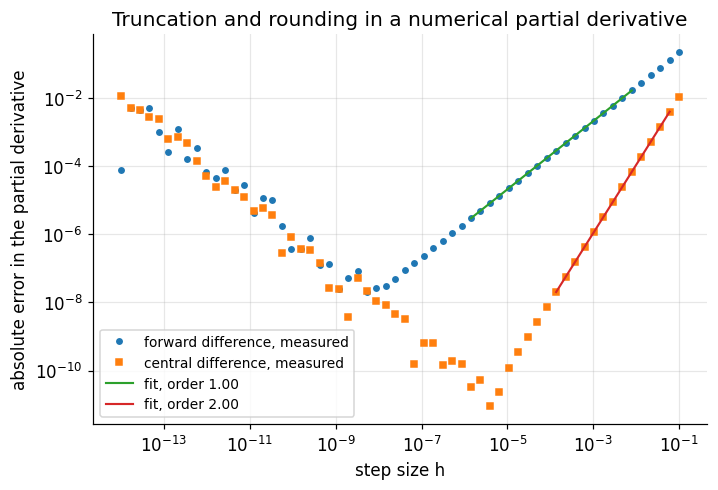

In [6]:
def fun(p):
    x, y = p
    return np.sin(x * y) + x**3 * y


def exact_partial_x(p):
    x, y = p
    return y * np.cos(x * y) + 3 * x**2 * y


pt = np.array([0.7, 1.3])
truth = exact_partial_x(pt)
e1 = np.array([1.0, 0.0])
hs = np.logspace(-1, -14, 60)

fwd = np.array([abs((fun(pt + hh * e1) - fun(pt)) / hh - truth) for hh in hs])
ctr = np.array([abs((fun(pt + hh * e1) - fun(pt - hh * e1)) / (2 * hh) - truth) for hh in hs])

trunc = (hs > 1e-6) & (hs < 1e-2)
slope_f = np.polyfit(np.log(hs[trunc]), np.log(fwd[trunc]), 1)[0]
trunc_c = (hs > 1e-4) & (hs < 1e-1)
slope_c = np.polyfit(np.log(hs[trunc_c]), np.log(ctr[trunc_c]), 1)[0]

print(f"exact d f / d x at (0.7, 1.3) = {truth:.12f}")
print(f"forward difference: observed order {slope_f:.4f}   predicted 1")
print(f"central difference: observed order {slope_c:.4f}   predicted 2")
print(f"best forward step  h = {hs[fwd.argmin()]:.2e}, error {fwd.min():.2e}"
      f"   (theory ~ sqrt(eps) = {np.sqrt(EPS):.2e})")
print(f"best central step  h = {hs[ctr.argmin()]:.2e}, error {ctr.min():.2e}"
      f"   (theory ~ eps^(1/3) = {EPS ** (1 / 3):.2e})")
assert abs(slope_f - 1.0) < 0.05
assert abs(slope_c - 2.0) < 0.05

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.loglog(hs, fwd, "o", ms=3.5, label="forward difference, measured")
ax.loglog(hs, ctr, "s", ms=3.5, label="central difference, measured")
ax.loglog(hs[trunc], np.exp(np.polyval(np.polyfit(np.log(hs[trunc]), np.log(fwd[trunc]), 1),
                                       np.log(hs[trunc]))), lw=1.4,
          label=f"fit, order {slope_f:.2f}")
ax.loglog(hs[trunc_c], np.exp(np.polyval(np.polyfit(np.log(hs[trunc_c]), np.log(ctr[trunc_c]), 1),
                                         np.log(hs[trunc_c]))), lw=1.4,
          label=f"fit, order {slope_c:.2f}")
ax.set_xlabel("step size h")
ax.set_ylabel("absolute error in the partial derivative")
ax.set_title("Truncation and rounding in a numerical partial derivative")
ax.legend(fontsize=9)
plt.show()

The fitted orders are $1.00$ and $2.00$ against predictions of $1$ and $2$, and both curves turn
upward once rounding takes over. The optimal steps land near $\sqrt{\varepsilon_{\mathrm{mach}}}$
and $\varepsilon_{\mathrm{mach}}^{1/3}$, the classical balance points.

The practical reading: a partial derivative asked of a black-box function costs one extra
evaluation per coordinate at first order, two at second order, and can never be trusted below
about $10^{-11}$.

### 7.3 The counterexamples of Proposition 4.6, run

The next cell walks each of the five functions of Example 6.6 around circles of shrinking radius
and prints what survives:

- the value of $f$ on the circle, which detects failure of continuity;
- the supremum over the circle of $\lvert f(h) - Lh \rvert / \lVert h \rVert$ with $L$ read off
  the partials at the origin, which is exactly the Frechet quotient of Definition 3.7.

(i)   xy/(x^2+y^2)
    r = 1e-01   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 5.0000e+00
    r = 1e-02   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 5.0000e+01
    r = 1e-03   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 5.0000e+02
    r = 1e-04   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 5.0000e+03
    r = 1e-05   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 5.0000e+04
(ii)  x^2 y/(x^4+y^2)
    r = 1e-01   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 4.9998e+00
    r = 1e-02   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 4.9999e+01
    r = 1e-03   f range on circle [-0.5000, +0.5000]   sup |E|/||h|| = 4.9997e+02
    r = 1e-04   f range on circle [-0.4999, +0.4999]   sup |E|/||h|| = 4.9993e+03
    r = 1e-05   f range on circle [-0.4999, +0.4999]   sup |E|/||h|| = 4.9987e+04
(iii) x^3/(x^2+y^2)
    r = 1e-01   f range on circle [-0.1000, +0.1000]   sup |E|/||h|| = 3.8490e-01
    r = 1e-02   f range on circle [-0

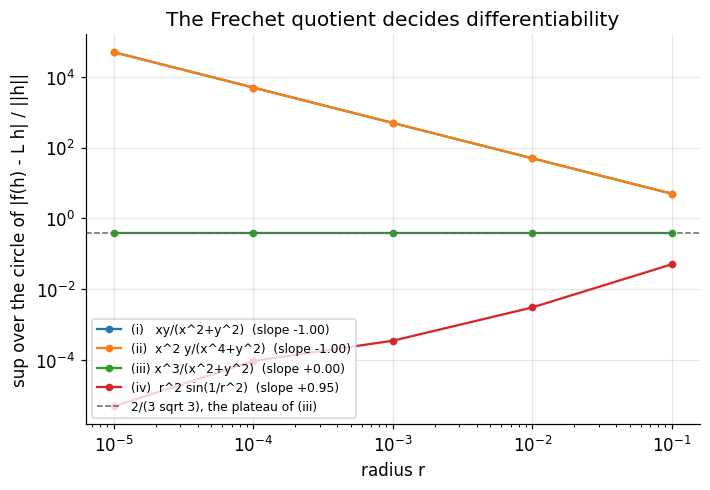

In [7]:
# The angular grid is refined near the axes, where these functions take their extremes;
# a plain uniform grid misses the maximizer of (ii), which sits at sin(theta) = r.
base = np.linspace(0.0, 2.0 * np.pi, 2001)[:-1]
fine = np.logspace(-9.0, -1.0, 400)
theta = np.unique(np.concatenate([base, fine, np.pi - fine, np.pi + fine,
                                  2.0 * np.pi - fine]))
radii = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5])

cases = {
    "(i)   xy/(x^2+y^2)":            (lambda X, Y: X * Y / (X**2 + Y**2), np.array([0.0, 0.0])),
    "(ii)  x^2 y/(x^4+y^2)":         (lambda X, Y: X**2 * Y / (X**4 + Y**2), np.array([0.0, 0.0])),
    "(iii) x^3/(x^2+y^2)":           (lambda X, Y: X**3 / (X**2 + Y**2), np.array([1.0, 0.0])),
    "(iv)  r^2 sin(1/r^2)":          (lambda X, Y: (X**2 + Y**2) * np.sin(1.0 / (X**2 + Y**2)),
                                      np.array([0.0, 0.0])),
    "(v)   |x|":                     (lambda X, Y: np.abs(X), None),
}

sup_table = {}
for name, (func, Lvec) in cases.items():
    print(name)
    if Lvec is None:
        q = (np.abs(1e-6) - 0.0) / 1e-6
        qm = (np.abs(-1e-6) - 0.0) / (-1e-6)
        print(f"    partial in x at (0,0): right quotient {q:+.1f}, left quotient {qm:+.1f}"
              "  -> no limit, partial does not exist")
        continue
    sups = []
    for r in radii:
        X, Y = r * np.cos(theta), r * np.sin(theta)
        vals = func(X, Y)
        rem = np.abs(vals - (Lvec[0] * X + Lvec[1] * Y)) / r
        sups.append(rem.max())
        print(f"    r = {r:.0e}   f range on circle [{vals.min():+.4f}, {vals.max():+.4f}]"
              f"   sup |E|/||h|| = {rem.max():.4e}")
    sup_table[name] = np.array(sups)

slopes = {k: np.polyfit(np.log(radii), np.log(v), 1)[0] for k, v in sup_table.items()}
print("\nfitted slope of sup |E|/||h|| against r (log-log):")
for k, s in slopes.items():
    print(f"    {k:28s} {s:+.4f}")
assert abs(slopes["(i)   xy/(x^2+y^2)"] + 1.0) < 0.02
assert abs(slopes["(ii)  x^2 y/(x^4+y^2)"] + 1.0) < 0.05
assert abs(slopes["(iii) x^3/(x^2+y^2)"]) < 0.02
assert abs(slopes["(iv)  r^2 sin(1/r^2)"] - 1.0) < 0.35
assert abs(sup_table["(iii) x^3/(x^2+y^2)"][-1] - 2 / (3 * np.sqrt(3))) < 1e-3

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for name, vals in sup_table.items():
    ax.loglog(radii, vals, "o-", ms=4, label=f"{name}  (slope {slopes[name]:+.2f})")
ax.axhline(2 / (3 * np.sqrt(3)), ls="--", lw=1.0, color="0.4",
           label="2/(3 sqrt 3), the plateau of (iii)")
ax.set_xlabel("radius r")
ax.set_ylabel("sup over the circle of |f(h) - L h| / ||h||")
ax.set_title("The Frechet quotient decides differentiability")
ax.legend(fontsize=8, loc="lower left")
plt.show()

The three regimes are visible as three slopes, and they are exactly the three cases of
Definition 3.7.

Functions (i) and (ii) have slope $-1$: the quotient **blows up** like $1/r$, so no linear map
can work, and indeed both are discontinuous at the origin — the value of (i) on the circle stays
between $-1/2$ and $+1/2$ at every radius.

Function (iii) has slope $0$: the quotient sits on the constant $2/(3\sqrt3) = 0.3849$ forever.
It never diverges, so the function is continuous with every directional derivative present, and
it never tends to $0$, so it is not differentiable. This is the sharpest of the counterexamples.

Function (iv) has slope $\approx 1$, decaying like $r$ as the bound $r$ from Proof 5.6 predicts;
the fitted slope wobbles because $\sin(1/r^2)$ oscillates. It is differentiable at the origin and
still not $C^1$.

Function (v) never reaches the table: its $x$-partial at the origin does not exist at all,
because the right and left quotients are $+1$ and $-1$. Continuity buys nothing.

### 7.4 A hand-rolled Jacobian against SciPy and SymPy

The last experiment implements a central-difference Jacobian from scratch and checks it against
`scipy.optimize.approx_fprime`, which uses a forward difference, and against the exact SymPy
Jacobian.

In [8]:
from scipy.optimize import approx_fprime


def jacobian_central(func, x, h=1e-5):
    """Central-difference Jacobian of func: R^n -> R^m at x."""
    x = np.asarray(x, dtype=float)
    f0 = np.atleast_1d(func(x))
    J = np.zeros((f0.size, x.size))
    for j in range(x.size):
        step = np.zeros_like(x)
        step[j] = h
        J[:, j] = (np.atleast_1d(func(x + step)) - np.atleast_1d(func(x - step))) / (2 * h)
    return J


def vecfun(p):
    x, y, z = p
    return np.array([x**2 * y + np.sin(z), np.exp(x * z) - y**3])


pv = np.array([0.4, -1.1, 0.9])

sx, sy, sz = sp.symbols("sx sy sz", real=True)
sym = sp.Matrix([sx**2 * sy + sp.sin(sz), sp.exp(sx * sz) - sy**3])
J_exact = np.array(sp.matrix2numpy(
    sym.jacobian(sp.Matrix([sx, sy, sz])).subs({sx: pv[0], sy: pv[1], sz: pv[2]}).evalf(),
    dtype=float))

J_mine = jacobian_central(vecfun, pv)
J_scipy = np.vstack([approx_fprime(pv, lambda q, i=i: vecfun(q)[i], np.sqrt(EPS))
                     for i in range(2)])

print("exact (SymPy):\n", J_exact)
print("hand-rolled central differences:\n", J_mine)
print("scipy.optimize.approx_fprime (forward):\n", J_scipy)
print(f"\n||mine  - exact||_max = {np.abs(J_mine - J_exact).max():.3e}")
print(f"||scipy - exact||_max = {np.abs(J_scipy - J_exact).max():.3e}")
assert np.abs(J_mine - J_exact).max() < 1e-9
assert np.abs(J_scipy - J_exact).max() < 1e-6

exact (SymPy):
 [[-0.88    0.16    0.6216]
 [ 1.29   -3.63    0.5733]]
hand-rolled central differences:
 [[-0.88    0.16    0.6216]
 [ 1.29   -3.63    0.5733]]
scipy.optimize.approx_fprime (forward):
 [[-0.88    0.16    0.6216]
 [ 1.29   -3.63    0.5733]]

||mine  - exact||_max = 1.432e-10
||scipy - exact||_max = 6.437e-08


Both numerical Jacobians land on the exact one, and the accuracy gap is the content of Section
7.2: the central-difference version is more than two orders of magnitude more accurate than the
forward-difference library call, at twice the cost per column.

### 7.5 The corrected hierarchy

The final figure redraws the implication diagram. Solid arrows are the true implications
(Theorems 4.1 and 4.2); dashed arrows are the converses that fail, each labelled with the
function from Example 6.6 that breaks it.

The arrow from "continuous at $a$" down to "partials exist" that earlier versions of this module
drew is **not** present, because it is false — row (v) of Proposition 4.6.

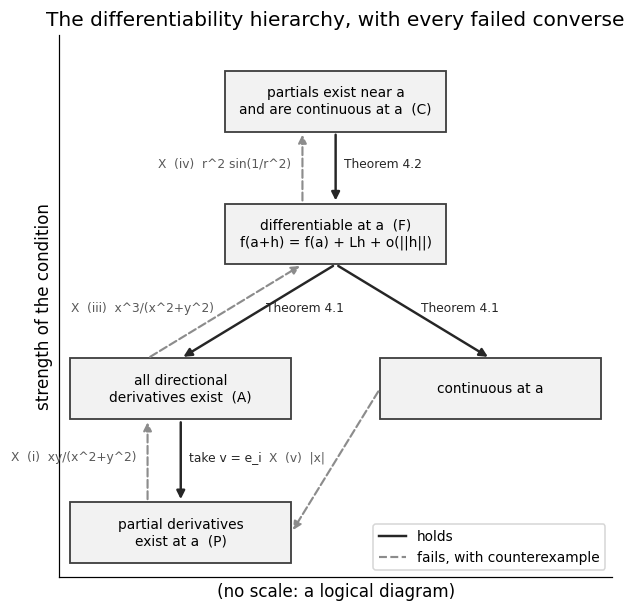

solid arrows : 4  dashed arrows : 4
note: there is NO arrow from 'continuous at a' to 'partials exist at a'


In [9]:
boxes = {
    "C1": (0.50, 0.86, "partials exist near a\nand are continuous at a  (C)"),
    "F":  (0.50, 0.62, "differentiable at a  (F)\nf(a+h) = f(a) + Lh + o(||h||)"),
    "A":  (0.22, 0.34, "all directional\nderivatives exist  (A)"),
    "K":  (0.78, 0.34, "continuous at a"),
    "P":  (0.22, 0.08, "partial derivatives\nexist at a  (P)"),
}

fig, ax = plt.subplots(figsize=(8.6, 6.4))
for key, (cx, cy, text) in boxes.items():
    ax.add_patch(plt.Rectangle((cx - 0.20, cy - 0.055), 0.40, 0.11,
                               fill=True, facecolor="0.95", edgecolor="0.25", lw=1.2))
    ax.text(cx, cy, text, ha="center", va="center", fontsize=9)

solid = [("C1", "F", "Theorem 4.2"), ("F", "A", "Theorem 4.1"),
         ("F", "K", "Theorem 4.1"), ("A", "P", "take v = e_i")]
for src, dst, lab in solid:
    x0, y0 = boxes[src][0], boxes[src][1] - 0.055
    x1, y1 = boxes[dst][0], boxes[dst][1] + 0.055
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color="0.15"))
    ax.text((x0 + x1) / 2 + 0.015, (y0 + y1) / 2, lab, fontsize=8, color="0.15")

dashed = [("F", "C1", "(iv)  r^2 sin(1/r^2)"),
          ("A", "F", "(iii)  x^3/(x^2+y^2)"),
          ("P", "A", "(i)  xy/(x^2+y^2)"),
          ("K", "P", "(v)  |x|")]
for src, dst, lab in dashed:
    x0, y0 = boxes[src][0] - 0.06, boxes[src][1] + 0.055
    x1, y1 = boxes[dst][0] - 0.06, boxes[dst][1] - 0.055
    if src == "K":
        x0, y0 = boxes["K"][0] - 0.20, boxes["K"][1]
        x1, y1 = boxes["P"][0] + 0.20, boxes["P"][1]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, ls="--", color="0.55"))
    ax.text((x0 + x1) / 2 - 0.02, (y0 + y1) / 2, "X  " + lab, fontsize=8,
            color="0.35", ha="right")

ax.plot([], [], color="0.15", lw=1.6, label="holds")
ax.plot([], [], color="0.55", lw=1.4, ls="--", label="fails, with counterexample")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 0.98)
ax.set_aspect("equal")
ax.set_xlabel("(no scale: a logical diagram)")
ax.set_ylabel("strength of the condition")
ax.set_title("The differentiability hierarchy, with every failed converse")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.legend(loc="lower right", fontsize=9)
plt.show()

print("solid arrows :", len(solid), " dashed arrows :", len(dashed))
print("note: there is NO arrow from 'continuous at a' to 'partials exist at a'")

Reading the figure downward: $C^1$ is the strongest condition and partial differentiability is
the weakest, with differentiability strictly between them.

Reading it upward: every dashed arrow is a theorem that does not exist, and each carries the
explicit function that refutes it. The one-way arrow from "continuous at $a$" to "partials exist"
is absent because "continuous" and "partials exist" are incomparable, not nested.

## 8. Applications

### 8.1 Backpropagation is Theorem 4.3

A feed-forward network is a composite $y = f_L \circ \cdots \circ f_1(x)$. Theorem 4.3 says the
Jacobian of the whole is the product of the layer Jacobians,

$$
J_y(x) = J_{f_L} \cdots J_{f_1} .
$$

For a scalar loss, $m = 1$ at the top, so multiplying **left to right** keeps a single row vector
at every step and costs $O(\text{one forward pass})$ per full gradient. Multiplying right to left
would carry an $n \times n$ matrix. That asymmetry, and nothing else, is why reverse-mode
automatic differentiation is the algorithm of record.

For the two-layer network $y = W_2 \sigma(W_1 x + b_1) + b_2$ with elementwise $\sigma$,

$$
\frac{\partial y}{\partial x} = W_2 \operatorname{diag}\bigl(\sigma'(W_1 x + b_1)\bigr) W_1 .
$$

A caution follows immediately from Proposition 4.6: with $\sigma = \operatorname{ReLU}$ the
network is **not** $C^1$, so Theorem 4.2 does not apply on the kink set and the object returned
by a framework there is a choice of subgradient, not a derivative.

### 8.2 Partial differential equations

Every field equation of classical physics is a statement about partial derivatives of a
multivariable function: with $\alpha, c \gt 0$,

$$
\frac{\partial u}{\partial t} = \alpha \nabla^2 u \quad \text{(heat)}, \qquad
\frac{\partial^2 u}{\partial t^2} = c^2 \nabla^2 u \quad \text{(wave)}, \qquad
\nabla^2 \Phi = 0 \quad \text{(Laplace)} .
$$

The Laplacian $\nabla^2 u = \sum_i \partial_i^2 u$ is well defined as written only because
Theorem 4.4 makes the order of differentiation irrelevant for $C^2$ solutions.

### 8.3 Maxwell relations are Theorem 4.4

For a thermodynamic system the internal energy $U(S,V)$ is a state function, so $dU$ is an exact
differential:

$$
dU = T \, dS - P \, dV \quad \Longrightarrow \quad \left(\frac{\partial U}{\partial S}\right)_V = T, \qquad \left(\frac{\partial U}{\partial V}\right)_S = -P .
$$

Applying Theorem 4.4 to $U$ gives $\partial_V \partial_S U = \partial_S \partial_V U$, that is

$$
\left(\frac{\partial T}{\partial V}\right)_S = -\left(\frac{\partial P}{\partial S}\right)_V .
$$

**Interpretation.** The relation is not a physical law but a bookkeeping identity: it holds for
every $C^2$ potential. Its content is that $U$ is a function of state at all, which is the first
law.

### 8.4 Level sets and optimization landscapes

A training loss $L(\theta)$ over $\theta \in \mathbb{R}^d$ has level sets $L(\theta) = c$, and
gradient descent moves perpendicular to them. Section 2 showed why $C^1$ matters here: only when
the partials are continuous does the linear model built from them actually approximate $L$, and
only then does a small step guarantee a decrease.

The eccentricity of the level sets is what a step size has to survive; the quantitative version
belongs to [calculus/12](../12_hessian_jacobian_curvature/) and
[calculus_optimization/03](../../calculus_optimization/03_gradient_descent_mechanics/).

The cell below runs all four applications on explicit small objects: the heat kernel residual,
the two-layer Jacobian against finite differences, the softmax Jacobian identity, and the Maxwell
relation on a concrete internal-energy function.

In [10]:
# --- 8.2 heat kernel solves the heat equation ---------------------------
st, sxx, sal = sp.symbols("t x alpha", positive=True)
kernel = 1 / sp.sqrt(4 * sp.pi * sal * st) * sp.exp(-sxx**2 / (4 * sal * st))
residual = sp.simplify(sp.diff(kernel, st) - sal * sp.diff(kernel, sxx, 2))
print("heat kernel residual u_t - alpha u_xx :", residual)
assert residual == 0

# --- 8.1 two-layer network Jacobian -------------------------------------
d0, d1, d2 = 4, 5, 3
W1 = rng.standard_normal((d1, d0))
b1 = rng.standard_normal(d1)
W2 = rng.standard_normal((d2, d1))
b2 = rng.standard_normal(d2)
act = np.tanh
dact = lambda z: 1.0 - np.tanh(z) ** 2

net = lambda p: W2 @ act(W1 @ p + b1) + b2
xin = rng.standard_normal(d0)
J_formula = W2 @ np.diag(dact(W1 @ xin + b1)) @ W1
J_fd = jacobian_central(net, xin, h=1e-5)
err_net = np.abs(J_formula - J_fd).max()
print(f"\ntwo-layer network: ||W2 diag(sigma') W1 - central differences||_max = {err_net:.3e}")
assert err_net < 1e-8

# --- 8.1 softmax Jacobian identity --------------------------------------
z = rng.standard_normal(5)
s = np.exp(z - z.max())
s = s / s.sum()
J_soft_formula = np.diag(s) - np.outer(s, s)
J_soft_fd = jacobian_central(lambda q: np.exp(q - q.max()) / np.exp(q - q.max()).sum(), z)
err_soft = np.abs(J_soft_formula - J_soft_fd).max()
print(f"softmax: ||diag(s) - s s^T - central differences||_max = {err_soft:.3e}")
print("row sums of the softmax Jacobian (must vanish):", J_soft_formula.sum(axis=1))
assert err_soft < 1e-8
assert np.abs(J_soft_formula.sum(axis=1)).max() < 1e-12

# --- 8.3 Maxwell relation on a concrete potential ------------------------
S, V = sp.symbols("S V", positive=True)
U = S**2 / V + sp.log(S * V) + S * V
T_expr = sp.diff(U, S)
P_expr = -sp.diff(U, V)
lhs = sp.simplify(sp.diff(T_expr, V))
rhs = sp.simplify(-sp.diff(P_expr, S))
print("\n(dT/dV)_S =", lhs, "    -(dP/dS)_V =", rhs, "    equal:", sp.simplify(lhs - rhs) == 0)
assert sp.simplify(lhs - rhs) == 0
print("\nall assertions passed")

heat kernel residual u_t - alpha u_xx : 0

two-layer network: ||W2 diag(sigma') W1 - central differences||_max = 2.195e-10
softmax: ||diag(s) - s s^T - central differences||_max = 8.153e-12
row sums of the softmax Jacobian (must vanish): [ 0. -0.  0. -0.  0.]

(dT/dV)_S = -2*S/V**2 + 1     -(dP/dS)_V = -2*S/V**2 + 1     equal: True

all assertions passed


The heat kernel residual is symbolically zero, so the identity holds for every $\alpha$ and every
$t \gt 0$, not merely at sampled points.

The two-layer Jacobian formula and the softmax formula both match central differences to about
$10^{-10}$, the accuracy ceiling of Section 7.2, and the softmax rows sum to zero to machine
precision — the statement that the softmax output always sums to one, differentiated.

The Maxwell relation is verified symbolically on a concrete $U(S,V)$; the equality is Theorem 4.4
applied to a function that happens to be called internal energy.

## 9. Key Takeaways

- **The derivative is a linear map, not a list of numbers.** $f$ is differentiable at $a$ when
  one linear $L$ satisfies $f(a+h) = f(a) + Lh + o(\lVert h \rVert)$; that $L$ is unique, forces
  continuity, and its matrix is the Jacobian (Theorem 4.1).

- **Continuous partials are enough** (Theorem 4.2). The proof telescopes the increment along the
  coordinate directions, applies the one-variable mean value theorem to each piece, and uses
  continuity of the partials only at the single point $a$. This is the theorem that makes the
  subject usable, because partials are computable and Definition 3.7 is not.

- **The hierarchy is strict and it is not a chain.** $C^1 \Rightarrow$ differentiable
  $\Rightarrow$ all directional derivatives $\Rightarrow$ partials exist, with all four converses
  false; and continuity and the existence of partials are **incomparable** — $\lvert x \rvert$ is
  continuous with no $x$-partial on $x = 0$ (Proposition 4.6).

- **Composition becomes matrix multiplication** (Theorem 4.3), and the order in which the product
  is formed is exactly the difference between forward- and reverse-mode automatic
  differentiation.

- **Second derivatives commute when the mixed partial is continuous at the point**
  (Theorem 4.4) — and the theorem does not even assume the other mixed partial exists. Peano's
  function has both mixed partials everywhere, $-1$ and $+1$ at the origin, because $f_{xy}$ is
  discontinuous exactly there.

- **For $m \ge 2$ there is no exact mean value theorem**, only the inequality
  $\lVert f(y) - f(x) \rVert \le M \lVert y - x \rVert$ on a convex set (Theorem 4.5). The
  half-circle $\gamma(t) = (\cos t, \sin t)$ refutes every equality form.

- **An invertible derivative gives a quantitative lower bound**
  $\lVert f(y) - f(x) \rVert \ge \lambda \lVert y - x \rVert$ with
  $\lambda = 1/(2\lVert J_f(a)^{-1} \rVert_{\mathrm{op}})$, hence local injectivity
  (Proposition 4.8) — the half of the inverse function theorem this module proves.

- **Numerically, a partial derivative costs accuracy.** Forward differences are order $1$ and
  central differences order $2$, measured at $1.00$ and $2.00$ in Section 7.2, with optimal steps
  near $\sqrt{\varepsilon_{\mathrm{mach}}}$ and $\varepsilon_{\mathrm{mach}}^{1/3}$.

## 10. References

**Textbooks.**

- Rudin, W. *Principles of Mathematical Analysis*, 3rd ed., Ch. 9 — Theorem 9.15 (chain rule),
  Theorem 9.19 (mean value inequality), Theorem 9.21 (continuous partials characterize $C^1$ and
  give differentiability), Theorem 9.24 (inverse function theorem), Theorem 9.28 (implicit
  function theorem), Theorem 9.41 (the sharp mixed-partial theorem proved here as Theorem 4.4).
- Spivak, M. *Calculus on Manifolds*, Ch. 2 "Differentiation" — the derivative as a linear map,
  the chain rule, and the continuous-partials criterion, in the notation this module follows.
- Apostol, T. M. *Mathematical Analysis*, 2nd ed., Ch. 12 — total derivatives, the chain rule and
  the mixed-partial theorem, with the $\varepsilon$-$\delta$ machinery written out in full.
- Hubbard, J. H. and Hubbard, B. B. *Vector Calculus, Linear Algebra, and Differential Forms*,
  5th ed., sections 1.7-1.9 (derivative as a linear map, rules of differentiation, criterion for
  differentiability) and section 2.10 (inverse and implicit function theorems).
- Marsden, J. E. and Tromba, A. J. *Vector Calculus*, 6th ed., Ch. 2 — level sets, partial and
  directional derivatives, and the geometric reading used in Section 2.
- Demidovich, B. P. *Problems in Mathematical Analysis*, section VI — the classical source for
  the pathological limits and counterexamples of Proposition 4.6.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Limits, continuity and the $\varepsilon$-$\delta$ discipline reused throughout Section 3:
  [Module 02](../02_limits_and_continuity/).
- The one-variable mean value theorem, which Proof 5.2 and Proof 5.4 apply on each coordinate
  segment: [Module 03](../03_single_variable_derivatives/).
- Operator norms and the linear-algebra facts used in Proof 5.7:
  [linear_algebra/01](../../linear_algebra/01_vectors_spaces_and_subspaces/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).